In [1]:
%pip install ssl
%pip install pylatexenc
%pip install qiskit
%pip install qiskit_ibm_runtime

In [2]:
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeVigoV2

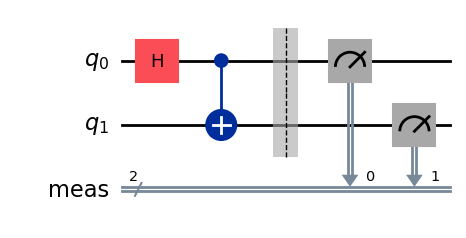

In [3]:
# Step 1: Create a Bell-state circuit
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()
circuit.draw(output="mpl")

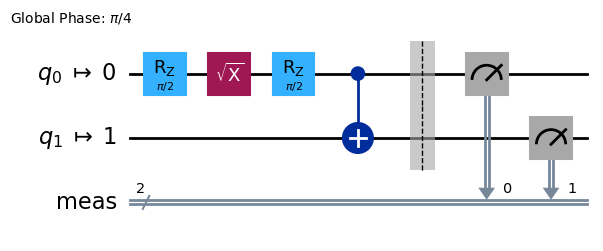

In [4]:
# Step 2: Transpile for a fake backend (for demonstration)
backend = FakeVigoV2()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)
isa_circuit.draw(output="mpl")

In [5]:
# Step 3: Run the Sampler primitive
sampler = Sampler(backend)

In [7]:
result = sampler.run([isa_circuit]).result()
counts = result[0].data.meas.get_counts()

<class 'RuntimeError'>: can't start new thread